# Auswerten eines Fragebogens - Teil 4: Fehlende Daten

In diesem Notebook werden die aus dem Fragebogen konstruierten Faktoren für Regressionsmodelle
verwendet. Im Mittelpunkt steht die explorative Innovation.

## Setup

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

import regression

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# Datensatz einlesen
df = pd.read_csv("daten/CPlus-zFaktoren.csv")
# Wir machen aus der ClusterNr einen String, um sie nie mit einer Zahl zu verwechseln
df["ClusterNr"] = ("cl" + df["ClusterNr"].astype(str)).astype("category")
df.head()

,ExploitInno,ExploreInno,ProcessInno,FirmPerf,TrustInRegion,EnvironDyn,EnvironComp,Strategy,ClusterMgmt,AbsorpCap,ClusterNr,FirmAgeLog,FirmSizeLog,CommonFactor
0,-0.572867,-0.681673,0.542874,0.781280,1.248619,1.427318,0.458966,-2.351391,-1.313565,-0.078726,cl12,3.321928,4.321928,-0.029515
1,0.908263,1.180415,-0.618077,0.167111,1.055931,0.189850,-0.393758,1.247677,-1.165194,0.765965,cl12,2.321928,2.584963,0.714543
2,-0.424754,-0.108722,0.542874,-1.982481,0.477867,0.543413,-0.820120,0.047988,-0.868450,0.441084,cl12,3.459432,3.584963,0.256661
3,0.315811,0.607465,0.929858,0.781280,0.670555,1.073756,-0.393758,0.347910,1.505495,0.246155,cl12,2.000000,3.321928,0.972102
4,-0.276641,0.177753,0.155890,0.167111,-0.678262,0.543413,0.245785,0.347910,-0.423336,0.376108,cl12,4.754888,8.451211,0.428367


### Abhängige Faktoren
- ExploitInno
- ExploreInno
- ProcessInno
- FirmPerf

### Unabhängige Faktoren
- TrustInRegion
- EnvironDyn
- EnvironComp
- Strategy
- ClusterMgmt
- AbsorpCap
- ClusterNr
- FirmAgeLog
- FirmSizeLog

In [4]:
# Definition für einfacheren Zugriff auf Spalten
params_abh = ["ExploitInno", "ExploreInno", "ProcessInno", "FirmPerf"]
params_unabh = ["TrustInRegion", "EnvironDyn", "EnvironComp", "Strategy", 
                "ClusterMgmt", "AbsorpCap", "ClusterNr", "FirmAgeLog", "FirmSizeLog"]

# Nur nummerische unabh. Variablen -- ohne ClusterNr
params_unabh_num = params_unabh.copy()
params_unabh_num.remove("ClusterNr")

In [5]:
# Für unsere Regression nehmen wir alle unabhängigen Variablen und ExploreInno.
df_expl1 = df[params_unabh + ["ExploreInno"]]

In [6]:
# Erstes Modell -- mit fehlenden Datensätzen
m1 = regression.fit_ols("ExploreInno ~ TrustInRegion + Strategy + ClusterMgmt + ClusterNr + "
                        "FirmAgeLog + FirmSizeLog + EnvironDyn + EnvironComp + AbsorpCap", df_expl1)
print(m1.summary())

# Wir sehen, dass nur 189 Datensätze verwendet worden sind, und dass ca. 58% der Varianz im Datensatz
# durch dieses Modell erklärt wird (R²).

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     12.17
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           7.54e-23
Time:                        16:58:35   Log-Likelihood:                -184.91
No. Observations:                 189   AIC:                             409.8
Df Residuals:                     169   BIC:                             474.7
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.3426      0.24

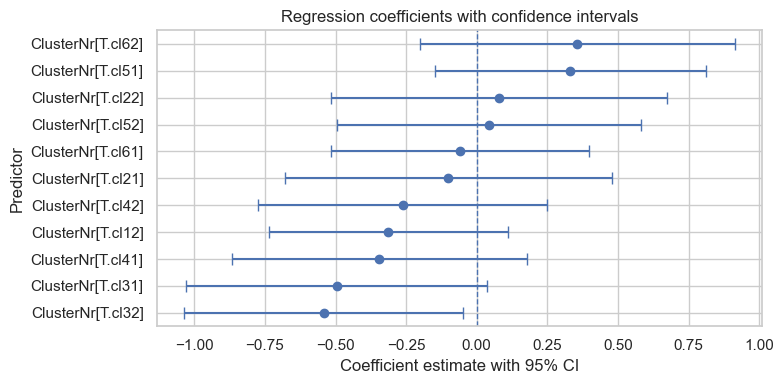

In [7]:
regression.plot_coef(m1, "ClusterNr")
# Offensichtlich gibt es Unterschiede zwischen den Clustern.
# Allerdings sind diese Unterschiede nicht super groß, sondern eher graduell.

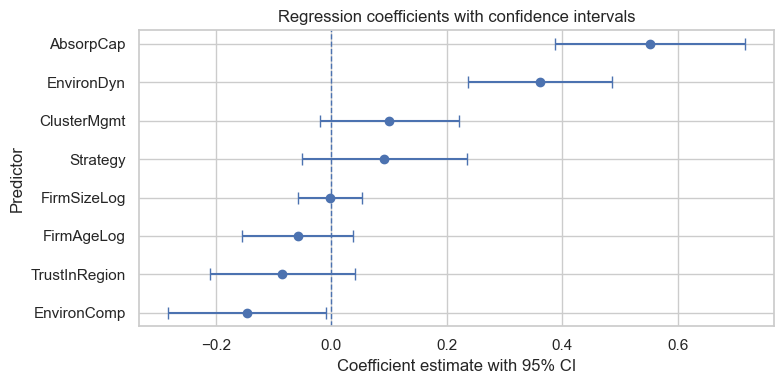

In [8]:
regression.plot_coef(m1, exclude="ClusterNr")

# Wir sehen, dass die Absorptionskapazität der einflussreichste Faktor ist,
# gefolgt von der Dynamik des Marktes und der Konkurrenzsituation im Markt.
# (Man nimmt immer den absoluten Betrag, wenn es um die Effektgröße geht.)

# Im Allgemeinen kann man von den Koeffizienten nicht auf die Effektgröße schließen.
# Da bei unserem Modell aber die unabhängigen Variablen z-transformiert sind, können wir direkt
# von der Größe der Koeffizienten auf die Effektgröße schließen. Davon ausgenommen: FirmSizeLog und FirmAgeLog,
# da diese nicht z-transformiert sind, also eine Std.-Abweichung != 1 haben.

<Axes: >

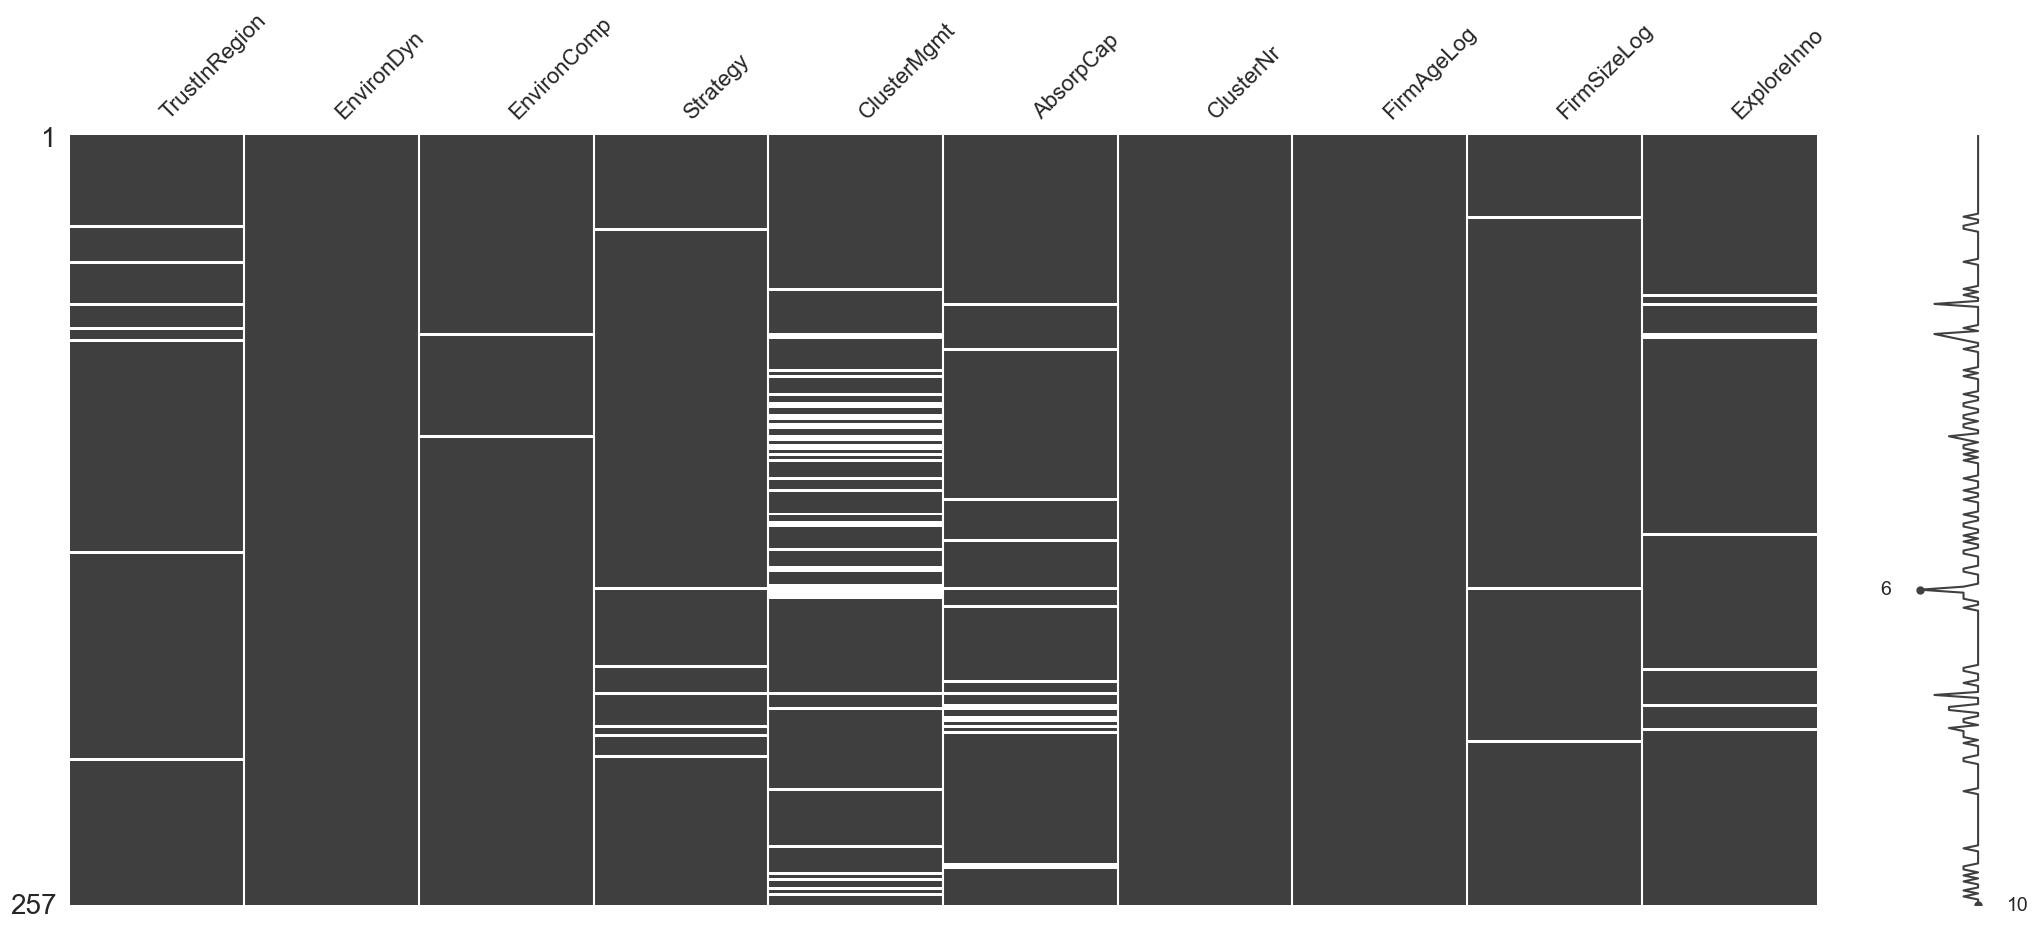

In [9]:
import missingno as mno

mno.matrix(df_expl1)
# Besonders beim Cluster-Management sowie bei der Absorptionskapazität fehlen viele Daten.

<Axes: >

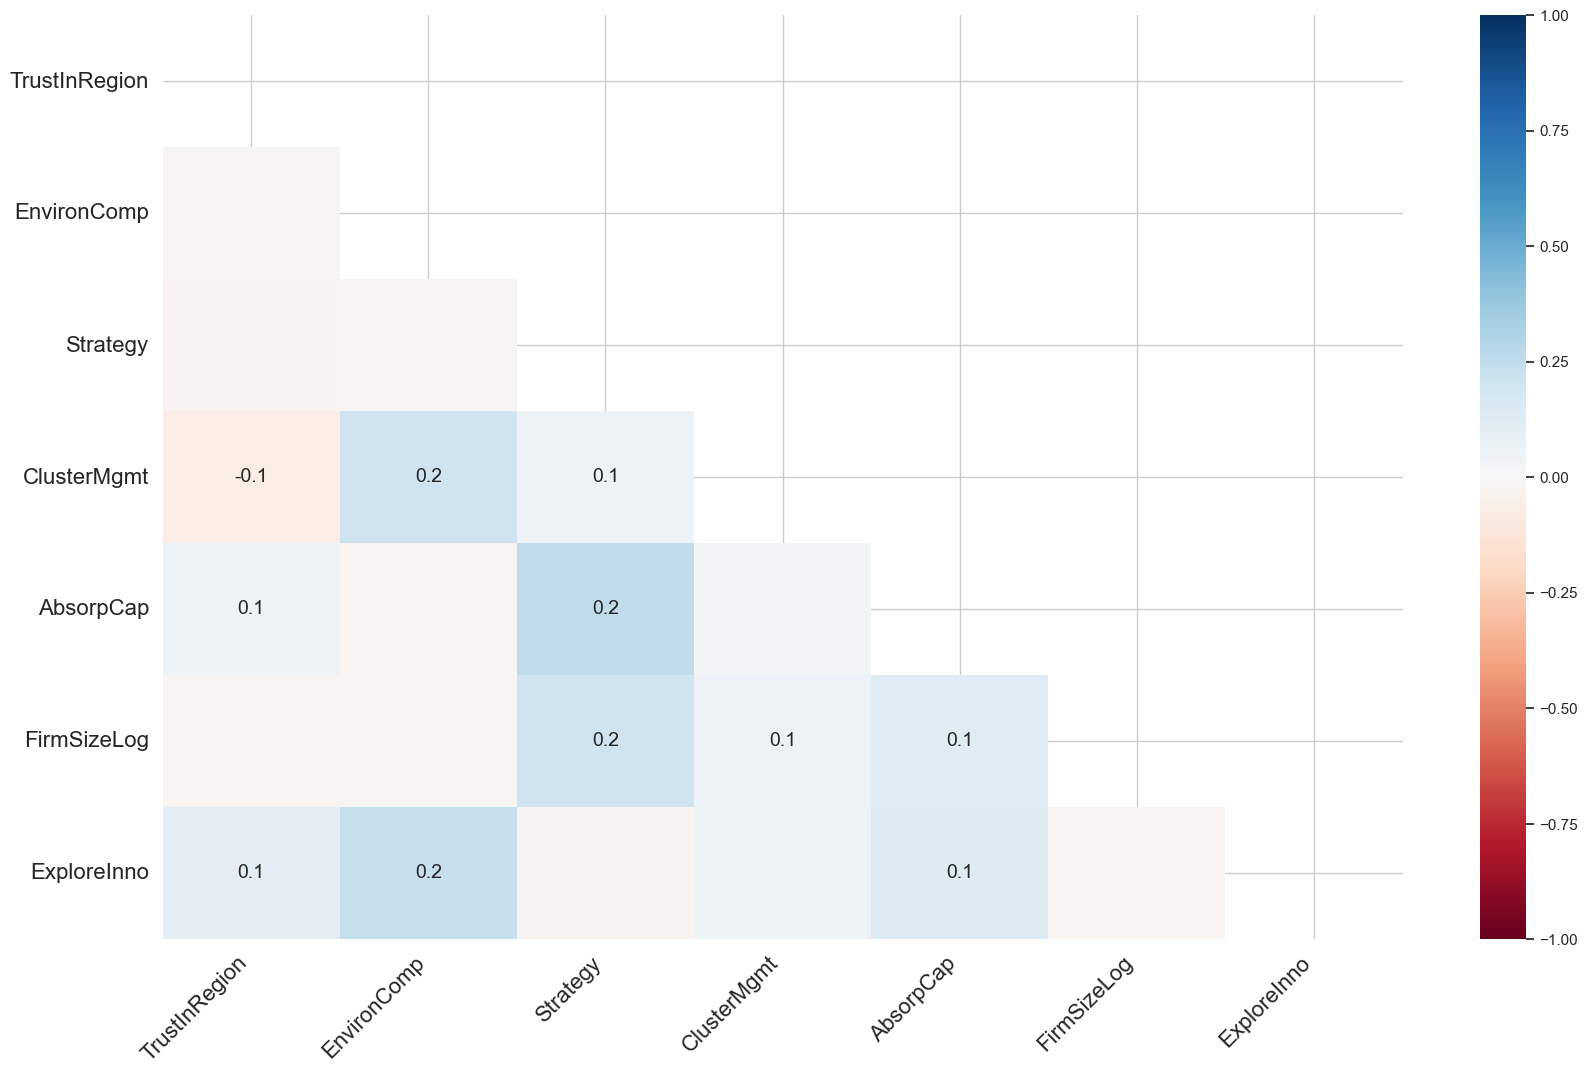

In [10]:
mno.heatmap(df_expl1)
# Allerdings ist nur eine schwache Korrelation vorhanden, das heißt, das Fehlen eines Datenpunktes
# in einer Variable korreliert nicht mit dem Fehlen in einer anderen Variable.

# Strategie 1: Fehlende Daten durch Mittelwert bzw. Median ersetzen

Das ist die einfachste Strategie. Jeder fehlende Wert wird durch den Mittelwert bzw. Median der jeweiligen Variable ersetzt.

Bei z-skalierten Variablen entspricht Mittelwert-Imputation dem Einsetzen von 0, da der Mittelwert nach der Standardisierung 0 ist. Median-Imputation ist insbesondere bei schiefen Verteilungen oder Ausreißern robuster. In vielen Anwendungen ist jedoch die Frage wichtiger, ob überhaupt eine einfache Ein-Wert-Imputation angemessen ist, da sowohl Mittelwert als auch Median die Varianz künstlich reduzieren.

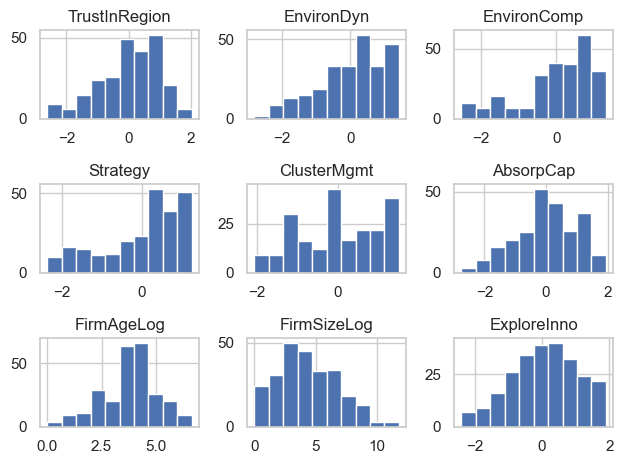

In [15]:
df_expl1.hist()
plt.tight_layout()

In [16]:
df_expl1.median(numeric_only=True).round(3)

TrustInRegion    0.092
EnvironDyn       0.190
EnvironComp      0.246
Strategy         0.348
ClusterMgmt     -0.052
AbsorpCap        0.051
FirmAgeLog       4.000
FirmSizeLog      4.248
ExploreInno      0.035
dtype: float64

In [17]:
# Wir verwenden den Median, da einige Variablen etwas schieflastig sind
# (z.B. Strategy oder EnvironComp)
df_expl2 = df_expl1.copy()
df_expl2 = df_expl2.fillna(df_expl2.median(numeric_only=True))

<Axes: >

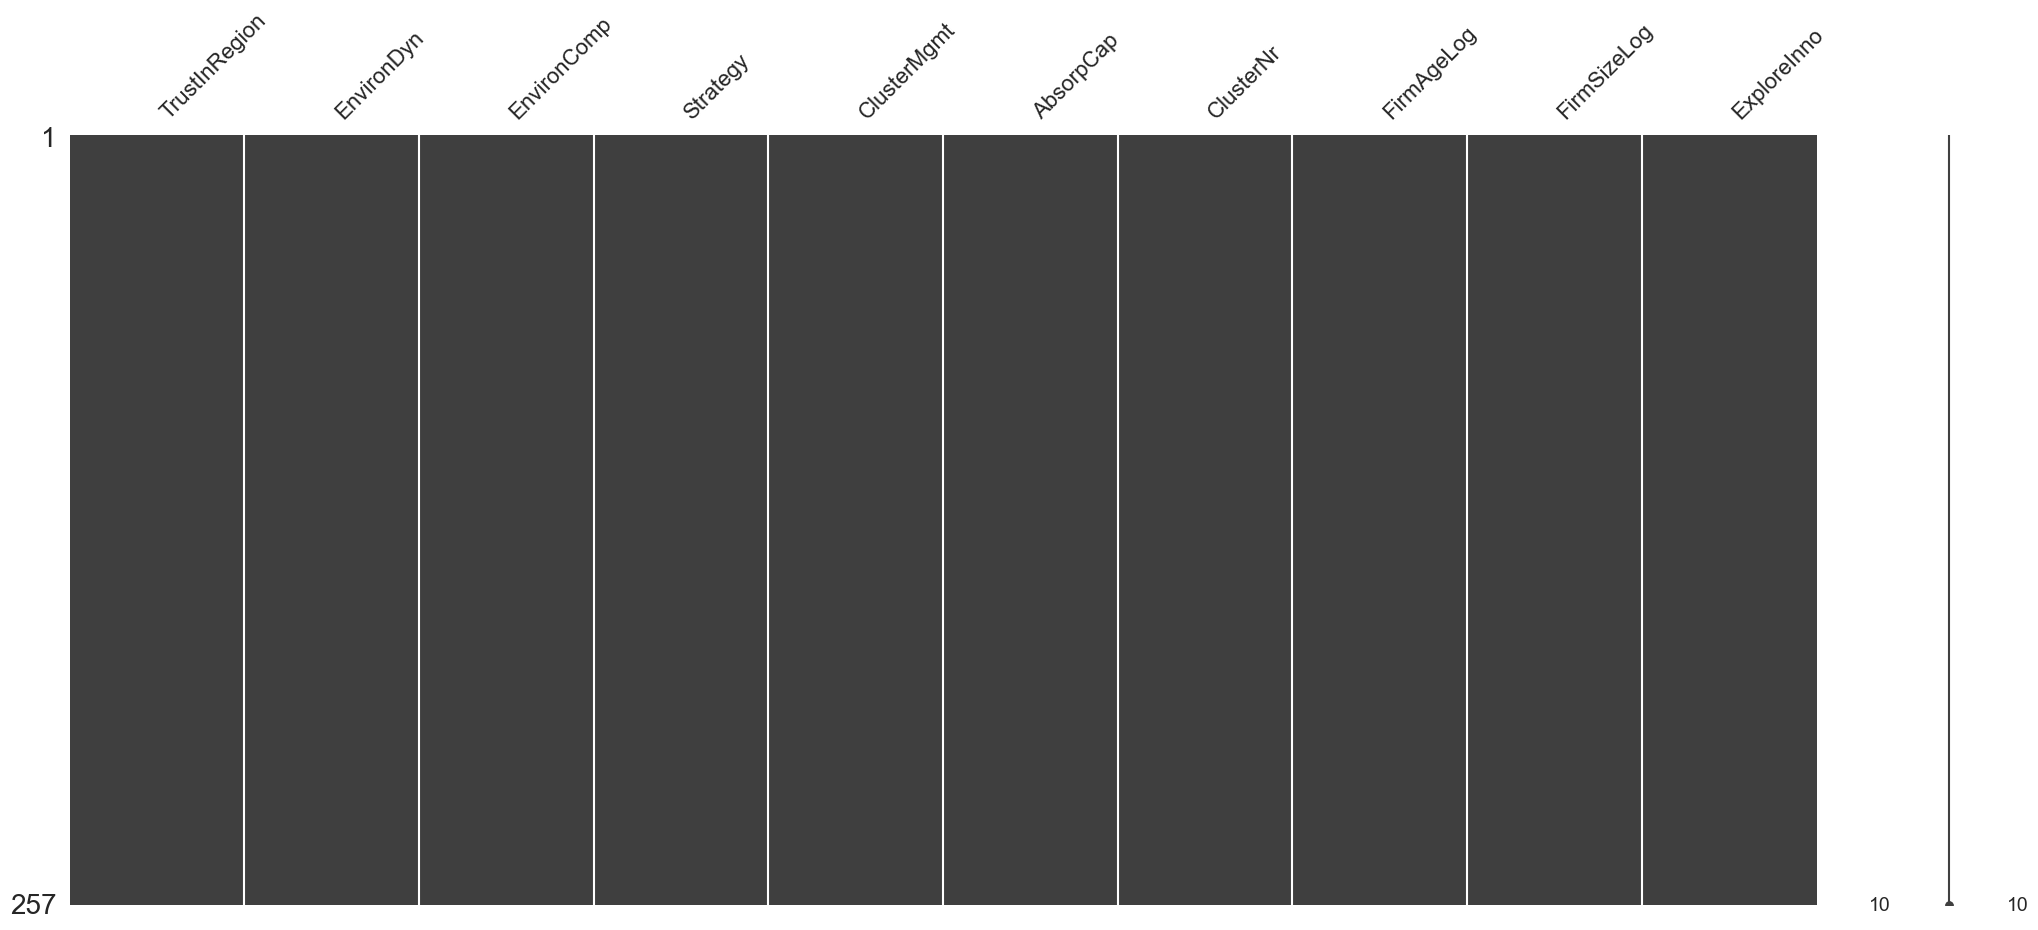

In [18]:
mno.matrix(df_expl2)
# Keine fehlenden Daten mehr :o)

In [19]:
m2 = smf.ols(m1.model.formula, data=df_expl2).fit()
print(m2.summary())

# Wir sehen, dass nun alle 257 Datensätze verwendet werden. Allerdings ist auch das R² schlechter als vorher.
#
# Dieser Rückgang bedeutet nicht automatisch, dass das imputierte Modell schlechter ist,
# da M1 und M2 auf unterschiedlichen Stichproben beruhen.
#
# Einerseits kann einfache Imputation die Varianz in den Variablen reduzieren und dadurch
# Zusammenhänge abschwächen. Andererseits enthalten die zusätzlich einbezogenen Fälle
# möglicherweise andere Muster als die zuvor vollständigen Fälle.
#
# Das höhere R² im "Complete-Case-Modell" (m1) kann daher auch darauf zurückzuführen sein,
# dass nur eine homogenere Teilstichprobe modelliert wurde.

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.514
Model:                            OLS   Adj. R-squared:                  0.475
Method:                 Least Squares   F-statistic:                     13.21
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.28e-27
Time:                        17:01:24   Log-Likelihood:                -267.30
No. Observations:                 257   AIC:                             574.6
Df Residuals:                     237   BIC:                             645.6
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.2034      0.22

In [25]:
df_expl1["complete_case"] = df_expl1.notna().all(axis=1)
df_expl1.groupby("complete_case")["ExploreInno"].describe() # sieht unterschiedlich aus

,count,mean,std,min,25%,50%,75%,max
complete_case,,,,,,,,
False,60.0,0.022579,1.029627,-2.400523,-0.681673,0.106134,0.893940,1.896603
True,189.0,-0.007168,0.993093,-2.257285,-0.681673,0.034515,0.750703,1.896603


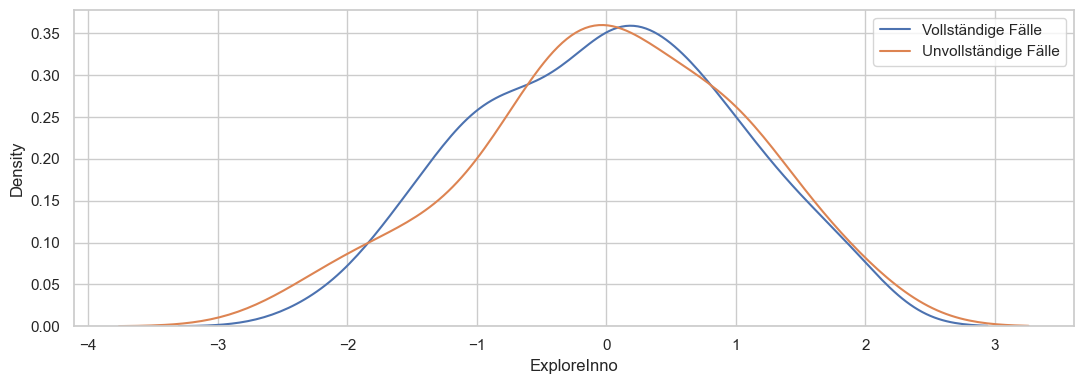

In [55]:
fig, axes = plt.subplots(figsize=(11, 4))
sns.kdeplot(df_expl1.query("complete_case == True"), x="ExploreInno", ax=axes, label="Vollständige Fälle")
sns.kdeplot(df_expl1.query("complete_case == False"), x="ExploreInno", ax=axes, label="Unvollständige Fälle")
axes.legend()
plt.tight_layout()
# Ein Unterschied in der Verteilung ist erkennbar

In [28]:
df_expl1.groupby("complete_case")[params_unabh_num].mean().round(3)
# Auch die unabhängigen Variablen weißen Unterschiede auf

,TrustInRegion,EnvironDyn,EnvironComp,Strategy,ClusterMgmt,AbsorpCap,FirmAgeLog,FirmSizeLog
complete_case,,,,,,,,
False,0.074,0.120,0.042,0.082,-0.244,0.139,3.988,4.529
True,-0.024,-0.043,-0.015,-0.027,0.037,-0.038,3.769,4.372


## Mittelwert je Gruppe (anstatt selber Mittelwert überall)

In [56]:
# Der Mittelwert je Cluster bei den einzelnen Variablen
df_expl1.groupby(by="ClusterNr").mean().round(3)

,TrustInRegion,EnvironDyn,EnvironComp,Strategy,ClusterMgmt,AbsorpCap,FirmAgeLog,FirmSizeLog,ExploreInno,complete_case
ClusterNr,,,,,,,,,,
cl11,0.687,0.296,-0.240,0.692,0.384,0.358,4.203,6.521,0.413,0.840
cl12,0.547,0.671,-0.266,-0.228,-0.222,0.025,3.832,4.938,0.000,1.000
cl21,-0.999,0.543,0.607,0.844,0.281,0.549,3.284,4.305,0.620,0.769
cl22,-0.643,0.040,0.423,0.348,0.049,0.165,4.655,5.844,0.165,0.615
cl31,0.304,-0.046,0.331,0.341,0.482,0.255,4.161,5.259,-0.231,0.476
cl32,0.732,0.656,0.285,0.627,0.782,1.079,3.765,3.388,0.542,0.727
cl41,-0.305,-0.296,0.246,-0.233,0.427,0.358,3.217,3.720,-0.136,0.812
cl42,-0.172,-0.051,0.416,0.185,0.002,0.096,3.389,5.248,0.040,0.480
cl51,-0.075,-0.289,0.210,-0.583,-0.609,-0.577,4.727,3.181,-0.204,0.917


In [57]:
df_expl3 = df_expl1.copy()
# Füllt Mittelwert pro Gruppe
df_expl3[params_unabh_num] = df_expl3.groupby(by="ClusterNr")[params_unabh_num].transform(lambda x: x.fillna(x.mean()))
# zur Sicherheit: sollte eine Gruppe nur NA gehabt haben, dann mit mean() der gesamten Spalte füllen
df_expl3 = df_expl3.fillna(df_expl3.mean(numeric_only=True))

In [58]:
m3 = smf.ols(m1.model.formula, data=df_expl3).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     13.54
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           3.10e-28
Time:                        17:26:10   Log-Likelihood:                -265.65
No. Observations:                 257   AIC:                             571.3
Df Residuals:                     237   BIC:                             642.3
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.2570      0.22

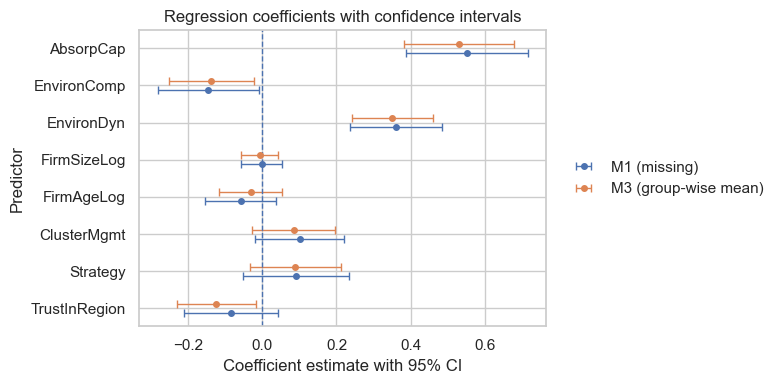

In [59]:
regression.plot_coef_compare([m1, m3], exclude="ClusterNr", names=["M1 (missing)", "M3 (group-wise mean)"])
# Wir sehen zwei Dinge:
# Erstens ist das Konfidenzintervall aller Parameter etwas kleiner als bei M1, wo weniger Datensätze verwendet werden können.
# Zweitens verschieben sich die Werte der Koeffizien selbst nur sehr geringfügig.
# Das heißt, die Imputation wirkt sich nicht wesentlich auf die Aussage unseres Modells aus.

# KNN-Imputation (k-Nearest Neighbour)

Es gibt eine Reihe von fortgeschritteren Imputationsverfahren, welche versuchen, sinnvolle Werte einzufüllen, nicht nur Mittelwerte.
Dadurch wird beispielsweise die Varianz im Datensatz nicht (so stark) vermindert wie bei einfacher Imputation mit Mittelwerten.

Ein solches Verfahren ist das KNN. Dort werden Daten für fehlende Datensätze aus deren "Nachbarschaft" gefüllt.
Die Nachbarschaft sind jene Daten, welche in ihren Werten für die bestehenden Variablen dem Datensatz, wo die Lücke ist, am ähnlichsten sind.

In [61]:
from sklearn.impute import KNNImputer

imp = KNNImputer(n_neighbors=5)

df_expl4 = df_expl1.copy()
df_expl4[params_unabh_num] = imp.fit_transform(df_expl4[params_unabh_num])

In [62]:
m4 = smf.ols(m1.model.formula, data=df_expl4).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:            ExploreInno   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     13.69
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           3.47e-28
Time:                        17:31:33   Log-Likelihood:                -258.35
No. Observations:                 249   AIC:                             556.7
Df Residuals:                     229   BIC:                             627.1
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.2858      0.22

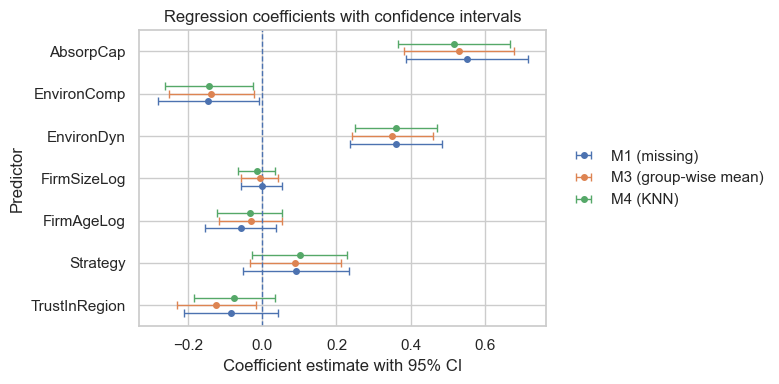

In [63]:
regression.plot_coef_compare([m1, m3, m4], exclude="Cluster", names=["M1 (missing)", "M3 (group-wise mean)", "M4 (KNN)"])

# Im Vergleich sehen wir wieder, dass bei M3 und M4 die Konfidenzintervalle geringer sind als wie beim ursprünglichen Modell M1.
# Wir sehen auch, dass je nach Imputationsverfahren die Koeffizienten selbst unterschiedlich ausfallen können.

# Besonders auffällig ist das beim Vertrauen in die Region (TrustInRegion), wo bei M3 der Koeffizient noch statistisch signifikant ist,
# weil er Null nicht einschließt. Bei der Imputation mit KNN (M4) ist der Koeffizient aber nicht mehr statistisch signifikant.